In [1]:
import plotly.express as px

In [ ]:
max_performance_dic_ASU_chunking = {
    '1 GPU': 50,
    '2 GPUs': 140,
    '3 GPUs': 160, 
    '4 GPUs': 180, 
    '5 GPUs': 210, 
    '6 GPUs': 230, 
    '7 GPUs': 250,
    '8 GPUs': 260,
}

max_performance_dic_ASU_no_chunking = {
    '1 GPU': ,
    '2 GPUs': ,
    '3 GPUs': , 
    '4 GPUs': , 
    '5 GPUs': 160, 
    '6 GPUs': , 
    '7 GPUs': ,
    '8 GPUs': ,
}

max_performance_dic_time_chunking = {
    '1 GPU': 306.37,
    '2 GPUs': 1998.74,
    '3 GPUs': 2957.33,
    '4 GPUs': 2726.10,
    '5 GPUs': 2715.57,
    '6 GPUs': 3440.59,
    '7 GPUs': 5099.87,
    '8 GPUs': 6000.34,
}

max_performance_dic_time_no_chunking = {
    '1 GPU': 306.37,
    '2 GPUs': 1998.74,
    '3 GPUs': 2957.33,
    '4 GPUs': 2726.10,
    '5 GPUs': 2715.57,
    '6 GPUs': 3440.59,
    '7 GPUs': 5099.87,
    '8 GPUs': 6000.34,
}

radius_dic_chunking = {
    '1 GPU': 42.384357,
    '2 GPUs': 68.961929,
    '3 GPUs': 70.162766,
    '4 GPUs': 70.770370,
    '5 GPUs': 70.221802,
    '6 GPUs': 73.267769,
    '7 GPUs': 68.748375,
    '8 GPUs': 68.748375,

}


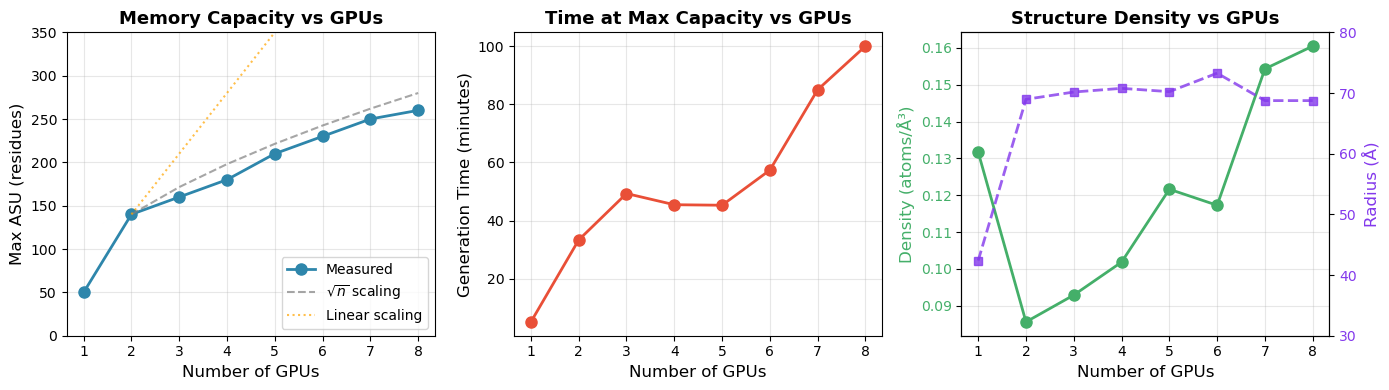

<Figure size 640x480 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt
import numpy as np


# Extract data
n_gpus = np.array([1, 2, 3, 4, 5, 6, 7, 8])
asu_max = np.array([max_performance_dic_ASU[f'{n} GPU' if n == 1 else f'{n} GPUs'] for n in n_gpus])
time_max = np.array([max_performance_dic_time[f'{n} GPU' if n == 1 else f'{n} GPUs'] for n in n_gpus])
radius = np.array([radius_dic[f'{n} GPU' if n == 1 else f'{n} GPUs'] for n in n_gpus])

# Derived quantities
tokens = asu_max * 60        # I = ASU × 60 chains
atoms = tokens * 14          # L ≈ 14 × I
volume = (4/3) * np.pi * radius**3  # Å³
density = atoms / volume     # atoms per Å³

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Max ASU vs GPUs
ax1 = axes[0]
ax1.plot(n_gpus, asu_max, 'o-', color='#2E86AB', linewidth=2, markersize=8, label='Measured')
sqrt_scaling = 140 * np.sqrt(n_gpus / 2)
ax1.plot(n_gpus[1:], sqrt_scaling[1:], '--', color='gray', alpha=0.7, label=r'$\sqrt{n}$ scaling')
linear_scaling = 140 * (n_gpus / 2)
ax1.plot(n_gpus[1:], linear_scaling[1:], ':', color='orange', alpha=0.7, label='Linear scaling')
ax1.set_xlabel('Number of GPUs', fontsize=12)
ax1.set_ylabel('Max ASU (residues)', fontsize=12)
ax1.set_title('Memory Capacity vs GPUs', fontsize=13, fontweight='bold')
ax1.set_xticks(n_gpus)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 350)

# Plot 2: Time vs GPUs (at max capacity)
ax2 = axes[1]
ax2.plot(n_gpus, time_max / 60, 'o-', color='#E94F37', linewidth=2, markersize=8)
ax2.set_xlabel('Number of GPUs', fontsize=12)
ax2.set_ylabel('Generation Time (minutes)', fontsize=12)
ax2.set_title('Time at Max Capacity vs GPUs', fontsize=13, fontweight='bold')
ax2.set_xticks(n_gpus)
ax2.grid(True, alpha=0.3)

# Plot 3: Density and Radius vs GPUs
ax3 = axes[2]
ax3.plot(n_gpus, density, 'o-', color='#44AF69', linewidth=2, markersize=8, label='Density')
ax3.set_xlabel('Number of GPUs', fontsize=12)
ax3.set_ylabel('Density (atoms/Å³)', fontsize=12, color='#44AF69')
ax3.set_title('Structure Density vs GPUs', fontsize=13, fontweight='bold')
ax3.set_xticks(n_gpus)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='y', labelcolor='#44AF69')

# Add radius on twin axis
ax3_twin = ax3.twinx()
ax3_twin.plot(n_gpus, radius, 's--', color='#8338EC', linewidth=2, markersize=6, alpha=0.8, label='Radius')
ax3_twin.set_ylabel('Radius (Å)', fontsize=12, color='#8338EC')
ax3_twin.tick_params(axis='y', labelcolor='#8338EC')
ax3_twin.set_ylim(30, 80)

plt.tight_layout()
plt.show()




from pathlib import Path
output_path = Path('/Users/kebl8661/remote/foundry/plotting/scaling_analysis.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')


## Theoretical dependencies to see where the bottleneck is

In [8]:
import plotly.express as px
import pandas as pd
import numpy as np

# Plot two functions (plotted interactively with plotly):
# 1. y = x^2 * 60  * 1/N  | "Tokens"
# 2. y = x * 60  * 1/N * 14 *  128 | "Atoms"
# I want N to be a slider across integer values from 1 to 8 GPUs
# The lineplots should be 2D and I want a slider to control the value of N (number of GPUs) from 1 to 8. The x-axis should be I (number of chains) from 50 to 300 in increments of 10. The y-axis should be the memory usage.  The plot should have a title and axis labels.
#y axis in log scale

i_values = np.arange(0, 300, 5)
n_values = np.arange(1, 9)
data = []
for n in n_values:
    tokens = i_values * i_values * 60 / n
    atoms = i_values * 60 * 14 * 128 / n
    for i, t, a in zip(i_values, tokens, atoms):
        data.append({'I (chains)': i, 'Memory Usage (Tokens)': t, 'Memory Usage (Atoms)': a, 'GPUs': n})
df = pd.DataFrame(data)
fig = px.line(df, x='I (chains)', y=['Memory Usage (Tokens)', 'Memory Usage (Atoms)'], color='variable',
              title='Memory Usage vs Number of Chains for Different GPU Counts',
              labels={'value': 'Memory Usage', 'I (chains)': 'Number of Chains', 'variable': 'Metric'},
              animation_frame='GPUs', range_y=[1, 30000000], )
fig.update_layout(legend_title_text='Metric')
#adda vertical line at x = 154
fig.add_vline(x=154, line_dash="dash", line_color="black", annotation_text="Natural particle (154 chains)", annotation_position="top right")
fig.show()